[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Segment Videos with Segment Anything 2 (SAM2)

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/facebookresearch/segment-anything-2)

Segment Anything Model 2 (SAM 2) is a foundation model designed to address promptable visual segmentation in both images and videos. The model extends its functionality to video by treating images as single-frame videos. Its design, a simple transformer architecture with streaming memory, enables real-time video processing. A model-in-the-loop data engine, which enhances the model and data through user interaction, was built to collect the SA-V dataset, the largest video segmentation dataset to date. SAM 2, trained on this extensive dataset, delivers robust performance across diverse tasks and visual domains.

![segment anything model](https://media.roboflow.com/notebooks/examples/segment-anything-model-2-paper.jpg)

This notebook is an extension of the official [notebook](https://github.com/facebookresearch/segment-anything-2/blob/main/notebooks/video_predictor_example.ipynb) prepared by Meta AI.

## Complementary materials

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-videos-with-sam-2.ipynb)
[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/what-is-segment-anything-2)

We recommend that you follow along in this notebook while reading the blog post on Segment Anything Model 2 (SAM2).

[![SAM2 blogpost](https://media.roboflow.com/notebooks/examples/blog-what-is-sam-2.png)](https://blog.roboflow.com/what-is-segment-anything-2)

## Setup

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Thu Jan 29 01:35:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


### Install SAM2 and dependencies

In [3]:
!git clone https://github.com/facebookresearch/segment-anything-2.git
%cd {HOME}/segment-anything-2
!pip install -e . -q
!python setup.py build_ext --inplace

fatal: destination path 'segment-anything-2' already exists and is not an empty directory.
/content/segment-anything-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
running build_ext
W0129 01:40:21.193000 3941 torch/utils/cpp_extension.py:630] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
W0129 01:40:21.245000 3941 torch/utils/cpp_extension.py:521] The detected CUDA version (12.5) has a minor version mismatch with the version that was used to compile PyTorch (12.6). Most likely this shouldn't be a problem.
W0129 01:40:21.246000 3941 torch/utils/cpp_extension.py:531] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.5


In [4]:
!pip install -q supervision[assets] jupyter_bbox_widget

### Download SAM2 checkpoints

**NOTE:** SAM2 is available in 4 different model sizes ranging from the lightweight "sam2_hiera_tiny" (38.9M parameters) to the more powerful "sam2_hiera_large" (224.4M parameters).

In [5]:
!mkdir -p {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt -P {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -P {HOME}/checkpoints

### Imports

In [6]:
import supervision as sv

In [7]:
import cv2
import torch
import base64

import numpy as np
import supervision as sv

from pathlib import Path
from supervision.assets import download_assets, VideoAssets
from sam2.build_sam import build_sam2_video_predictor

IS_COLAB = True

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

from jupyter_bbox_widget import BBoxWidget

In [8]:
from jupyter_bbox_widget import BBoxWidget

**NOTE:** This code enables mixed-precision computing for faster deep learning. It uses bfloat16 for most calculations and, on newer NVIDIA GPUs, leverages TensorFloat-32 (TF32) for certain operations to further boost performance.

In [9]:
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

## Load model

In [10]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = f"{HOME}/checkpoints/sam2_hiera_large.pt"
CONFIG = "sam2_hiera_l.yaml"

sam2_model = build_sam2_video_predictor(CONFIG, CHECKPOINT)

## Preprocess video

### Download video and split it into frames

**NOTE:** SAM2 assumee that the video is stored as a list of JPEG frames with filenames like `<frame_index>.jpg`. Let's start by downloading a sample video, splitting it into frames, and saving them to disk. Feel free to replace `SOURCE_VIDEO` with the path to your video file.

In [11]:
SOURCE_VIDEO = "/content/my_video_clip.mp4"
sv.VideoInfo.from_video_path(SOURCE_VIDEO)

VideoInfo(width=1920, height=1080, fps=60, total_frames=1560)

**NOTE:** To reduce VRAM requirements, we are introducing three additional parameters: `SCALE_FACTOR` to decrease the frame resolution, and `START_IDX` and `END_IDX` to extract only the relevant segments from the video.

In [12]:
SCALE_FACTOR = 1.0
START_IDX = 1
END_IDX = 700

In [13]:
SOURCE_FRAMES = Path(HOME) / Path(SOURCE_VIDEO).stem
SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)

frames_generator = sv.get_video_frames_generator(SOURCE_VIDEO, start=START_IDX, end=END_IDX)
images_sink = sv.ImageSink(
    target_dir_path=SOURCE_FRAMES.as_posix(),
    overwrite=True,
    image_name_pattern="{:05d}.jpeg"
)

with images_sink:
    for frame in frames_generator:
        frame = sv.scale_image(frame, SCALE_FACTOR)
        images_sink.save_image(frame)

TARGET_VIDEO = Path(HOME) / f"{Path(SOURCE_VIDEO).stem}-result.mp4"
SOURCE_FRAME_PATHS = sorted(sv.list_files_with_extensions(SOURCE_FRAMES.as_posix(), extensions=["jpeg"]))

### Initialize the inference state

**NOTE:** SAM 2 requires stateful inference for interactive video segmentation, so we need to initialize an inference state on this video. During initialization, it loads all the JPEG frames in `video_path` and stores their pixels in `inference_state` (as shown in the progress bar below).

In [14]:
inference_state = sam2_model.init_state(video_path=SOURCE_FRAMES.as_posix())

frame loading (JPEG): 100%|██████████| 699/699 [00:44<00:00, 15.75it/s]


**NOTE:** If you have run any previous tracking using this inference_state, please reset it first via reset_state. (The cell below is just for illustration; it's not needed to call reset_state here as this inference_state is just freshly initialized above.)

In [ ]:
sam2_model.reset_state(inference_state)

### Prompting with points

In [15]:
def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

**NOTE:** SAM2 allows tracking multiple objects at once. Update the `OBJECTS` list if you want to change the list of tracked objects.

In [16]:
OBJECTS = ['player-1', 'player-2', 'ball']

**NOTE:** Let's choose the index of the reference frame that we will use to annotate the objects we are looking for.

In [21]:
FRAME_IDX = 146
FRAME_PATH = Path(SOURCE_FRAMES) / f"{FRAME_IDX:05d}.jpeg"

widget = BBoxWidget(classes=OBJECTS)
widget.image = encode_image(FRAME_PATH)
widget

**NOTE:** The widget we are using stores annotations in a format that is inconsistent with SAM2's requirements. We parse them and then pass them to SAM2 via the `add_new_points` method. Each of the objects we track must be passed via a separate `add_new_points` call. It is important to specify `frame_idx` each time - the index of the frame to which the annotations relate, and `obj_id` - the ID of the object to which the annotations relate.

In [22]:
# Use add_new_points_or_box instead of add_new_points
for object_id, label in enumerate(OBJECTS, start=1):
    # Filter boxes for this specific player label
    player_boxes = [box for box in widget.bboxes if box['label'] == label]

    if len(player_boxes) == 0:
        continue

    # SAM 2 expects boxes in [x1, y1, x2, y2] format
    # Your widget gives [x, y, width, height]
    for box in player_boxes:
        input_box = np.array([
            box['x'],
            box['y'],
            box['x'] + box['width'],
            box['y'] + box['height']
        ], dtype=np.float32)

        # Call the correct function using the 'box' parameter
        _, object_ids, mask_logits = sam2_model.add_new_points_or_box(
            inference_state=inference_state,
            frame_idx=FRAME_IDX,
            obj_id=object_id,
            box=input_box,
        )


Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).


### Video inference

**NOTE:** To apply our point prompts to all video frames, we use the `propagate_in_video` generator. Each call returns `frame_idx` - the index of the current frame, `object_ids` - IDs of objects detected in the frame, and `mask_logits` - corresponding `object_ids` logit values, which we can convert to masks using thresholding.

In [23]:
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
video_info.width = int(video_info.width * SCALE_FACTOR)
video_info.height = int(video_info.height * SCALE_FACTOR)

COLORS = ['#FF1493', '#00BFFF', '#FF6347', '#FFD700']
mask_annotator = sv.MaskAnnotator(
    color=sv.ColorPalette.from_hex(COLORS),
    color_lookup=sv.ColorLookup.CLASS)

box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(COLORS),
    color_lookup=sv.ColorLookup.CLASS
)

frame_sample = []
list_xyxy = [] #guardo los rectangulos cuadro por cuadro

with sv.VideoSink(target_path= "/content/video_procesado.mp4", video_info=video_info) as sink:
    for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):
        frame_path = SOURCE_FRAME_PATHS[frame_idx]
        frame = cv2.imread(frame_path)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)

        detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks),
            mask=masks,
            class_id=np.array(object_ids)
        )
        list_xyxy.append(detections.xyxy)
        annotated_frame = frame.copy()
        annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)

        sink.write_frame(annotated_frame)
        if frame_idx % video_info.fps == 0:
            frame_sample.append(annotated_frame)

propagate in video: 100%|██████████| 553/553 [15:08<00:00,  1.64s/it]


In [24]:
#Check what list_xyxy looks like:
print(type(list_xyxy[0]))
print(list_xyxy[:5])

<class 'numpy.ndarray'>
[array([[ 760,  723,  874,  925],
       [ 975,  213, 1021,  313],
       [ 857,  572,  872,  593]]), array([[ 759,  723,  874,  925],
       [ 975,  214, 1021,  312],
       [ 858,  572,  871,  592]]), array([[ 749,  723,  873,  925],
       [ 972,  214, 1018,  314],
       [ 847,  607,  861,  630]]), array([[ 791,  723,  874,  925],
       [ 972,  214, 1018,  314],
       [ 847,  607,  862,  630]]), array([[ 748,  723,  873,  925],
       [ 972,  214, 1018,  314],
       [ 847,  608,  861,  630]])]


In [25]:
#convert the list in a 3d array (N,2,4)

data_array = np.array(list_xyxy)

print(data_array[:3])


[[[ 760  723  874  925]
  [ 975  213 1021  313]
  [ 857  572  872  593]]

 [[ 759  723  874  925]
  [ 975  214 1021  312]
  [ 858  572  871  592]]

 [[ 749  723  873  925]
  [ 972  214 1018  314]
  [ 847  607  861  630]]]


In [26]:
# Extract first elements [:, 0] and second [:, 1]
rectangles_p1 = data_array[:, 0, :]
rectangles_p2 = data_array[:, 1, :]
rectangles_ball = data_array[:, 2, :]

In [27]:
print(rectangles_p1[:3])

[[760 723 874 925]
 [759 723 874 925]
 [749 723 873 925]]


In [28]:
#save variables to reduce time

from google.colab import files

# 1. Create temporary file in Colab
np.save('rectangles_p1.npy', rectangles_p1)
np.save('rectangles_p2.npy', rectangles_p2)

# 2. Download locally
files.download('rectangles_p1.npy')
files.download('rectangles_p2.npy')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
#save variables to reduce time

from google.colab import files

np.save('rectangles_ball.npy', rectangles_ball)
files.download('rectangles_ball.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
#if we dont want to run everything we just import some essential libraries

import cv2
import torch
import base64

import numpy as np
import supervision as sv

from pathlib import Path

In [ ]:
#load in case that is needed
rectangles_p1 = np.load('rectangles_p1.npy')
rectangles_p2 = np.load('rectangles_p2.npy')
rectangles_ball = np.load('rectangles_ball.npy')

Check if the model performed correctly:

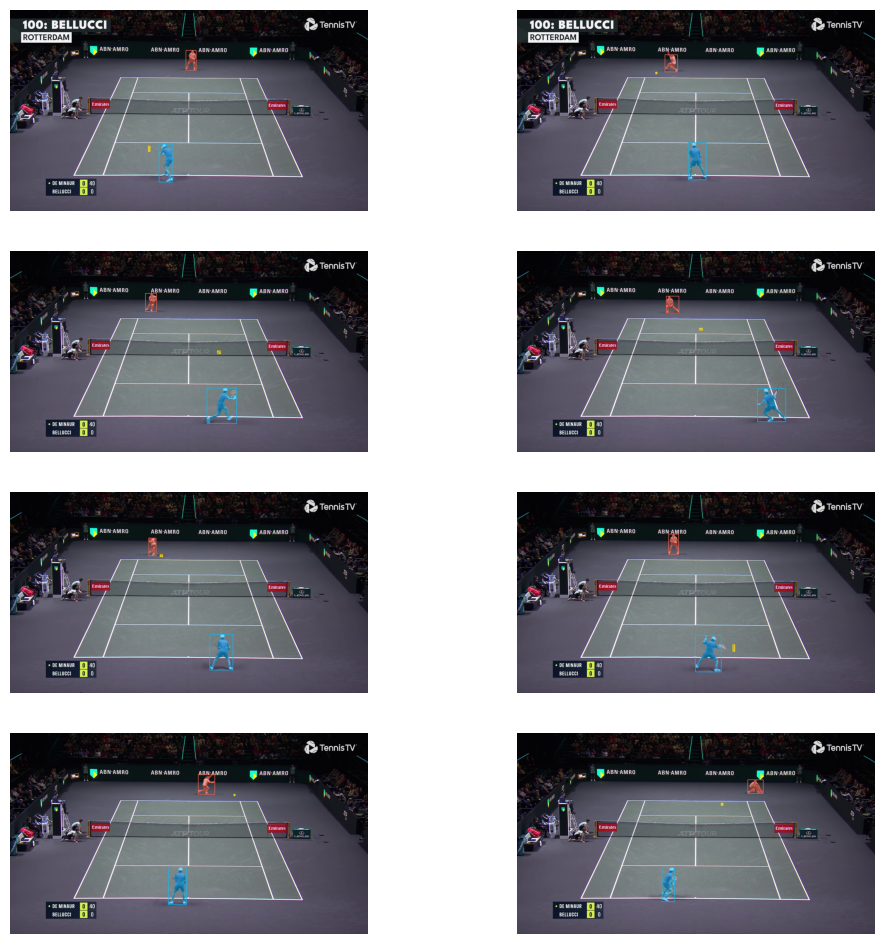

In [31]:
sv.plot_images_grid(
    images=frame_sample[:8],
    grid_size=(4, 2)
)

In order to generate a top_down vision of the court and the players' location, we need to map video_court coords to flat coords. This can be done manually by just taking note of the coords of the four corners of the court (or any 4 points). This is to be done manually because it can vary from video to video.

In [33]:
import plotly.express as px

# 1. Cargar el video y el frame deseado
#video_path = ".mp4" # <--- CAMBIA ESTO
frame_number = 130          # <--- Frame donde se ve bien la cancha

cap = cv2.VideoCapture(SOURCE_VIDEO)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
ret, frame = cap.read()
cap.release()

if ret:
    # Convertir a RGB para que los colores se vean bien
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 2. Crear imagen interactiva con Plotly
    fig = px.imshow(frame_rgb)

    # Ajustes para que sea fácil de ver
    fig.update_layout(
        title="Pasa el mouse para ver las coordenadas (x, y)",
        dragmode='zoom', # Permite hacer zoom si lo necesitas
        hovermode='closest' # Muestra la info del pixel más cercano
    )

    fig.show()
else:
    print("Error: No se pudo cargar el frame.")

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# TRANSFORMATION LOGIC

def get_homography_matrix(src_pts, dst_pts):
    H, status = cv2.findHomography(src_pts, dst_pts)
    return H

def transform_point(point, H):
    """
    Maps a single point (x, y) using the Homography matrix H.
    """
    # Convert to homogeneous coordinates [x, y, 1]
    pt_homogeneous = np.array([point[0], point[1], 1.0]).reshape(3, 1)

    # Dot product: H * point
    new_pt = np.dot(H, pt_homogeneous)

    # new_pt is a 3x1 matrix. We must access [row, col] to get the scalar value.
    # Otherwise, we are dividing single-element arrays, which causes a warning/error.
    scale_factor = new_pt[2, 0]

    new_x = new_pt[0, 0] / scale_factor
    new_y = new_pt[1, 0] / scale_factor

    return float(new_x), float(new_y)

# INPUT DATA

# Source Points (Pixels)
src_pts = np.float32([
    [592, 362],   # Top-Left
    [1327, 367],   # Top-Right
    [1571, 897],   # Bottom-Right
    [339, 890]     # Bottom-Left
])

# Destination Points (Meters)
dst_pts = np.float32([
    [0, 0],            # TL: Inicio Largo, Inicio Ancho
    [0, 10.97],        # TR: Inicio Largo, Fin Ancho
    [23.77, 10.97],    # BR: Fin Largo, Fin Ancho
    [23.77, 0]         # BL: Fin Largo, Inicio Ancho
])

# Calculate Matrix
H = get_homography_matrix(src_pts, dst_pts)

# --- New code to test transform_point ---
print("Testing transform_point function:")
for i, src_pt in enumerate(src_pts):
    transformed_pt = transform_point(src_pt, H)
    print(f"Original Point {i+1} (pixel): {src_pt}, Transformed Point (meter): {transformed_pt}")

# You can also test with a custom point, for example, the center of the court (roughly)
custom_point = (389, 198) # Example pixel point
transformed_custom_pt = transform_point(custom_point, H)
print(f"Custom Point (pixel): {custom_point}, Transformed Point (meter): {transformed_custom_pt}")

Testing transform_point function:
Original Point 1 (pixel): [592. 362.], Transformed Point (meter): (-3.865890216068803e-15, -1.9329451080344017e-15)
Original Point 2 (pixel): [1327.  367.], Transformed Point (meter): (-7.743830694000326e-15, 10.970000267028809)
Original Point 3 (pixel): [1571.  897.], Transformed Point (meter): (23.770000457763675, 10.970000267028809)
Original Point 4 (pixel): [339. 890.], Transformed Point (meter): (23.770000457763675, -2.3051616695319147e-15)
Custom Point (pixel): (389, 198), Transformed Point (meter): (-15.437195769709291, -5.275984507319768)


In [36]:
#verify correctness with one point (choose a significant point)
referencia = transform_point((445,116),H)
print(referencia)

(-26.8211554660517, -5.723371495358771)


In [37]:
import tennis_drawer as td
import path as cp

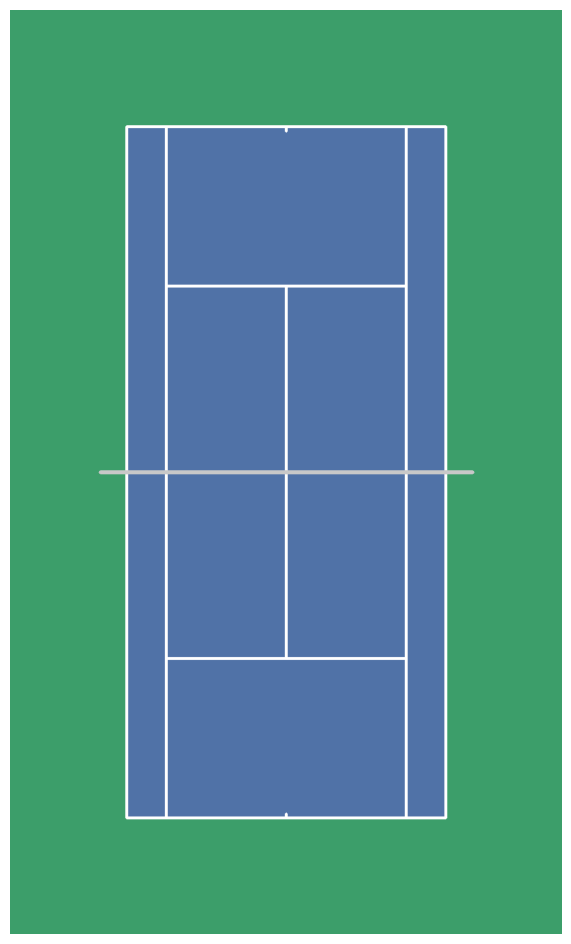

In [38]:
#print a top-down view of a tennis court
padding = 200
cancha_prueba = td.draw_court(padding=padding)
#td.cv2_imshow(cancha_prueba) also works
sv.plot_image(cancha_prueba)

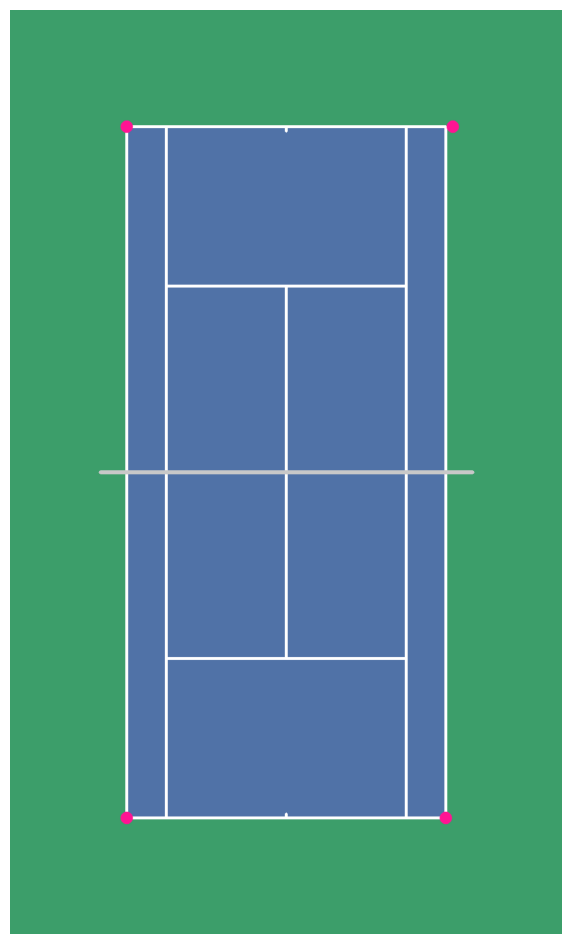

In [39]:
#draw points on a tennis court (note that we have to invert the components of each tuple we pass onto td.draw)
cancha_prueba = td.draw_points_on_court([referencia,(0,0),(23.77,10.97),(23.77,0),(0,11.2)],padding=padding)

#cancha_prueba = td.draw_points_on_court([(14.62,7.62)])

#td.cv2_imshow(cancha_prueba)
sv.plot_image(cancha_prueba)

In [40]:
def map_player_points_to_court(boxes_p1, boxes_p2):
  res = []
  # Iterate simultaneously over the bounding boxes for each player, assuming they are ordered by frame

  for box1, box2 in zip(boxes_p1, boxes_p2):
    # Calculate foot position for player 1 (bottom-center of the bounding box)
    foot_x_1 = (box1[0] + box1[2]) / 2  # (x_min + x_max) / 2
    foot_y_1 = box1[3]                   # y_max (bottom of the box)

    # Calculate foot position for player 2 (bottom-center of the bounding box)
    foot_x_2 = (box2[0] + box2[2]) / 2  # (x_min + x_max) / 2
    foot_y_2 = box2[3]                   # y_max (bottom of the box)

    # Transform pixel coordinates to court coordinates (meters)
    court_x_1, court_y_1 = transform_point((foot_x_1, foot_y_1), H)
    court_x_2, court_y_2 = transform_point((foot_x_2, foot_y_2), H)

    # Append the court coordinates for both players in the current frame
    res.append((court_x_1, court_y_1))
    res.append((court_x_2, court_y_2))
  return res

In [41]:
def map_ball_to_court(boxes_ball):
  res = []
  for box in boxes_ball:
    # Calculate position for the ball (center of the rectangle
    ball_point = (box[0] + box[2]) / 2, (box[1] + box[3]) / 2
    mapped_point = transform_point(ball_point, H)
    res.append(mapped_point)
  return res

In [42]:
mapped_points_ball = map_ball_to_court(rectangles_ball)
print(mapped_points_ball)

[(12.868149771260791, 4.39283516125205), (12.845137770657459, 4.392245541980618), (14.469525931571555, 4.3156849225160485), (14.469391721977983, 4.3213086962639204), (14.490943989603327, 4.316290640266529), (16.003577608891725, 4.228671885104843), (16.003454074021437, 4.234101111849402), (17.528212072820093, 4.155902676461805), (17.54678390654434, 4.1565383929967945), (-49.51317284588009, -20.897381176687624), (-49.51317284588009, -20.897381176687624), (-49.51317284588009, -20.897381176687624), (19.087866419750792, 4.017686077271614), (19.087866419750792, 4.017686077271614), (19.020377435059796, 3.9443447464524857), (19.020377435059796, 3.9443447464524857), (19.037633848817816, 3.945049011976883), (19.03939650184162, 3.8593067128266347), (19.03939650184162, 3.8593067128266347), (19.16130579776344, 3.789059894599959), (19.16130579776344, 3.789059894599959), (19.282672608886887, 3.7092195805385355), (19.299702075174785, 3.710020188652168), (19.282672608886887, 3.7092195805385355), (19.50

In [43]:
mapped_points_players = map_player_points_to_court(rectangles_p1,rectangles_p2)
print(mapped_points_players)
print(len(mapped_points_players))

[(24.614376202054824, 4.281208792609991), (-4.174869858939074, 6.089580182008231), (24.614447847050318, 4.276868875892824), (-4.261358033634761, 6.090288379940573), (24.61523591223785, 4.2291315949014585), (-4.086832563467797, 6.040970802986478), (24.612154983491372, 4.415759761723585), (-4.086832563467797, 6.040970802986478), (24.615307551822013, 4.2247920059771245), (-4.086832563467797, 6.040970802986478), (24.612656586861625, 4.385374989739049), (-4.085344686544751, 6.001054077618677), (24.612656586861625, 4.385374989739049), (-4.085344686544751, 6.001054077618677), (24.61308651501562, 4.359331965103491), (-4.08355934779209, 5.953157053627915), (24.61308651501562, 4.359331965103491), (-4.08355934779209, 5.953157053627915), (24.6133014730034, 4.346310821641449), (-4.08177413290543, 5.905263352711159), (24.6133014730034, 4.346310821641449), (-4.08177413290543, 5.905263352711159), (24.613229820791844, 4.350651175473504), (-4.08177413290543, 5.905263352711159), (24.613516426931866, 4.33

We should modify the code so that we can see in three different colors (to do)

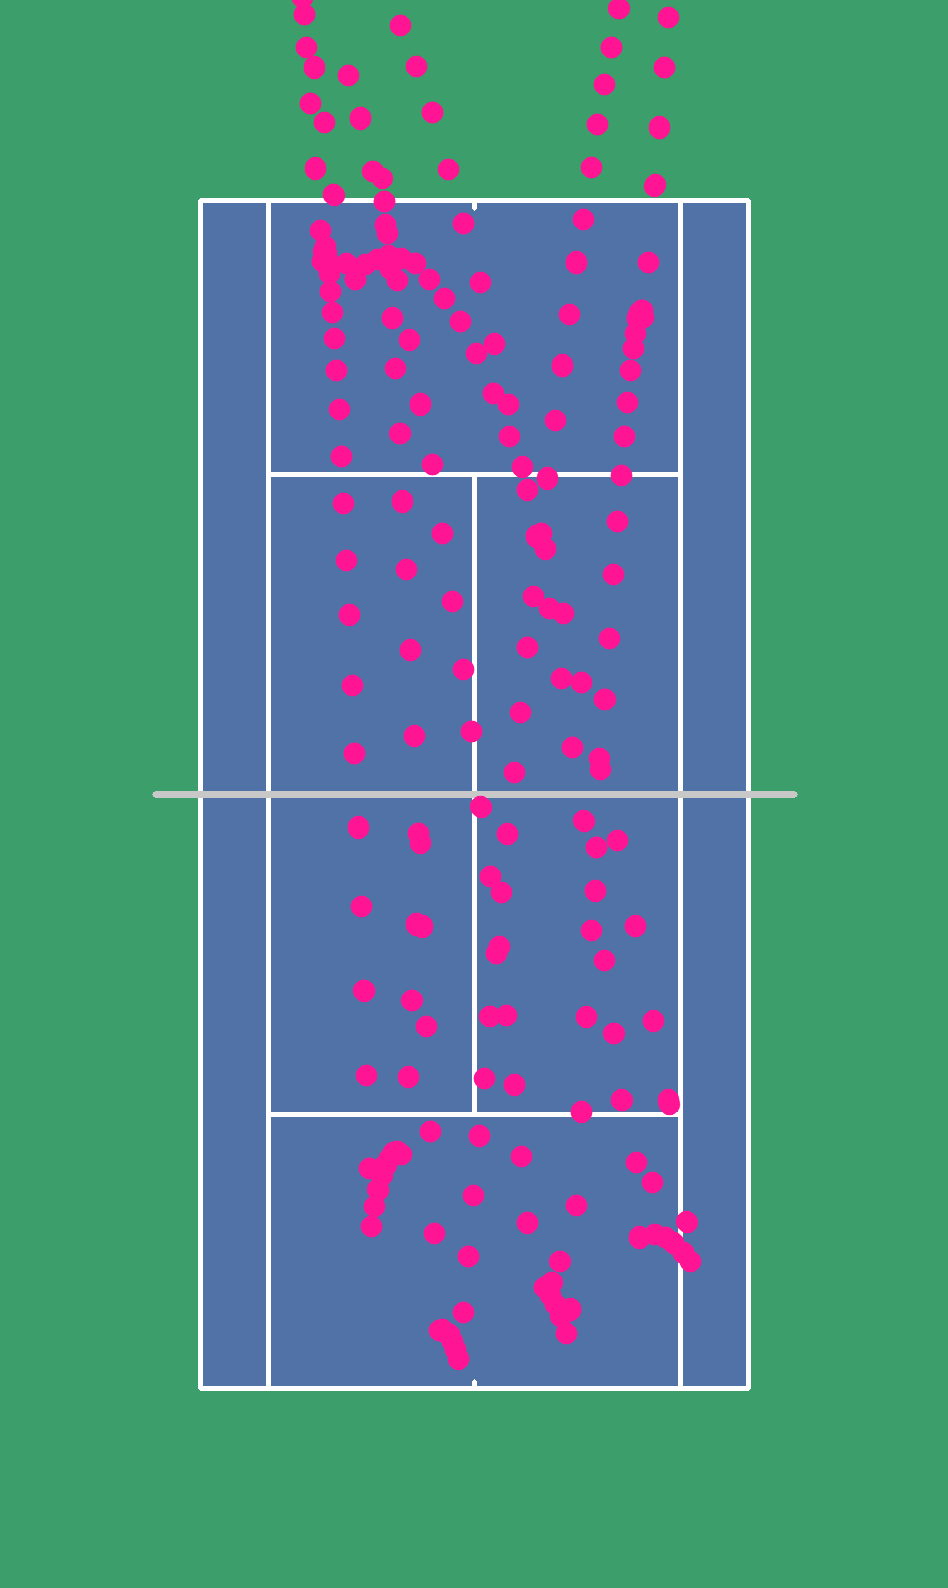

In [44]:
#draw court with ball points only

cancha_prueba = td.draw_points_on_court(mapped_points_ball,padding=padding)
td.cv2_imshow(cancha_prueba)

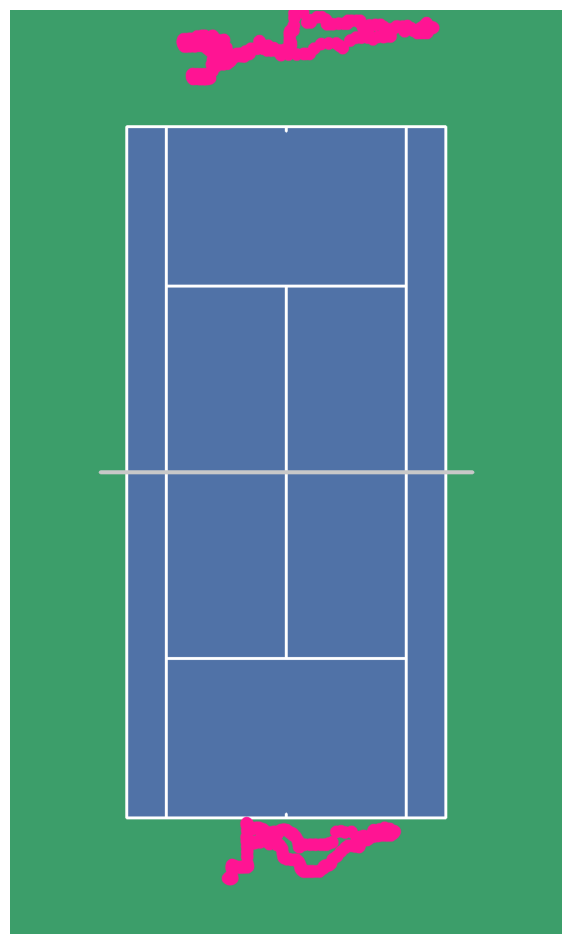

In [45]:
cancha_prueba = td.draw_points_on_court(mapped_points_players,padding=padding)
#td.cv2_imshow(cancha_prueba)
sv.plot_image(cancha_prueba)

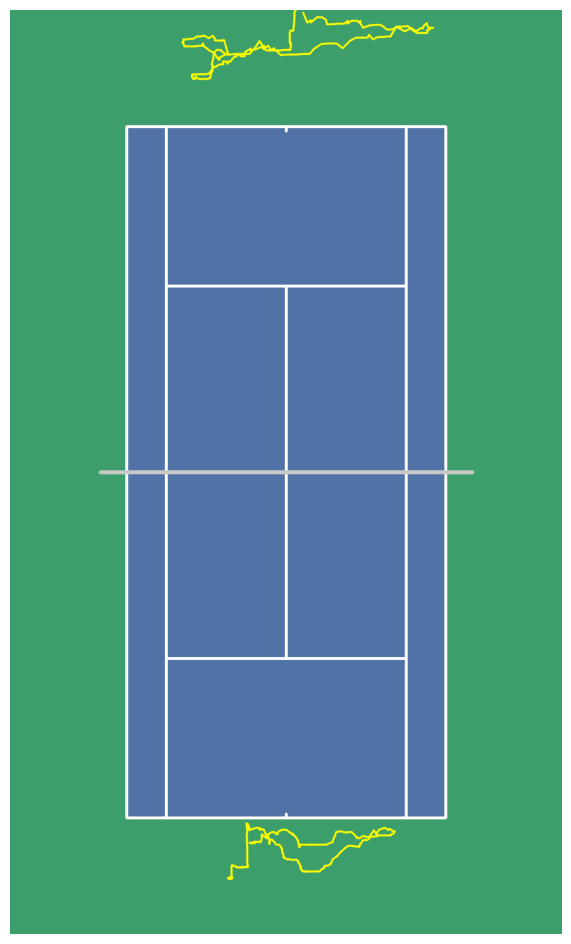

In [46]:
player1_path = mapped_points_players[0::2]
player2_path = mapped_points_players[1::2]
#ball_path = mapped_points[2::3] this doesnt work well because of the mapping we are using

all_paths = [player1_path, player2_path]

cancha_prueba = td.draw_paths_on_court(all_paths, padding=padding)
#td.cv2_imshow(cancha_prueba)
sv.plot_image(cancha_prueba)

In [47]:
# I need to create a variable video_xy that is an np.array and contains for each frame,
#the image of a court with both players locations drawn on it. For now we´ll leave ball tracking out of the video.

video_xy = []
i = 0
while i < len(mapped_points_players)-1:
  court_frame_i = td.draw_points_on_court([mapped_points_players[i], mapped_points_players[i+1]],padding=padding)
  video_xy.append(court_frame_i)
  i += 2
video_xy = np.array(video_xy)

In [ ]:
#video_xy = []
#for i in range(len(mapped_points)-1):
#  court_frame_i = td.draw_points_on_court([mapped_points[i], mapped_points[i+1]],padding=padding)
#  video_xy.append(court_frame_i)
#video_xy = np.array(video_xy)

In [48]:
import supervision as sv
from tqdm.notebook import tqdm
from pathlib import Path
import os
import cv2 # For getting image dimensions if needed

# Ensure HOME is defined if running this cell independently
HOME = Path(os.getcwd())

# Define SOURCE_VIDEO here to ensure it's available
SOURCE_VIDEO = "/content/my_video_clip.mp4"

# Define target video paths, assuming SOURCE_VIDEO is defined earlier
SOURCE_VIDEO_PATH = Path(SOURCE_VIDEO)
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-map.mp4"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed.mp4"

# Get video info from the generated frames in video_xy
# Assuming all frames in video_xy have the same dimensions and td.draw_court output is consistent
if len(video_xy) > 0:
    first_frame = video_xy[0]
    height, width, _ = first_frame.shape
    # Re-read original video info to get fps
    original_video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
    fps = original_video_info.fps
    total_frames = len(video_xy)
    video_info_out = sv.VideoInfo(width=width, height=height, fps=fps, total_frames=total_frames)
else:
    raise ValueError("video_xy is empty, cannot create video.")

print(f"Creating video from {len(video_xy)} frames...")
with sv.VideoSink(TARGET_VIDEO_PATH, video_info_out) as sink:
    for frame_image in tqdm(video_xy, desc="Writing video frames"):
        sink.write_frame(frame_image)

print(f"Video saved to {TARGET_VIDEO_PATH}")

# Compress the video
print(f"Compressing video to {TARGET_VIDEO_COMPRESSED_PATH}...")
!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}
print(f"Compressed video saved to {TARGET_VIDEO_COMPRESSED_PATH}")

Creating video from 553 frames...


Writing video frames:   0%|          | 0/553 [00:00<?, ?it/s]

Video saved to /content/segment-anything-2/my_video_clip-map.mp4
Compressing video to /content/segment-anything-2/my_video_clip-map-compressed.mp4...
Compressed video saved to /content/segment-anything-2/my_video_clip-map-compressed.mp4


In [49]:
from IPython.display import Video

Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)

In [50]:
import numpy as np

mapped_points = np.asarray(mapped_points_players, dtype=float)

# Sanity check
assert mapped_points.ndim == 2 and mapped_points.shape[1] == 2
assert mapped_points.shape[0] % 2 == 0  # must be divisible by number of objects (2 players)

P = 2  # Number of objects (2 players)
T = mapped_points.shape[0] // P

video_xy = mapped_points.reshape(T, P, 2)

In [51]:
video_xy.shape #now shape is proper for cleansing paths

(553, 2, 2)

In [52]:
#cleaned_xy, edited_mask = cp.clean_paths(video_xy)

cleaned_xy, edited_mask = cp.clean_paths(
    video_xy,
    jump_sigma=4.0,        # tennis motion is smoother
    min_jump_dist=0.4,     # smaller absolute jumps than basketball
    max_jump_run=4,        # tracking glitches are usually short
    pad_around_runs=1,
    smooth_window=11,      # tennis paths are longer & smoother
    smooth_poly=2,
)


In [53]:
# cleaned_xy has shape (T, 2, 2)

mapped_points_players_cleaned = [
    tuple(cleaned_xy[t, p])
    for t in range(cleaned_xy.shape[0])
    for p in range(cleaned_xy.shape[1])
]


In [54]:
# Original vs cleaned for first few points (just to check)
for i in range(6):
    print(mapped_points_players[i], "→", mapped_points_players_cleaned[i])


(24.614376202054824, 4.281208792609991) → (np.float64(24.61479606090147), np.float64(4.255775719234723))
(-4.174869858939074, 6.089580182008231) → (np.float64(-4.203969067187706), np.float64(6.091381830285253))
(24.614447847050318, 4.276868875892824) → (np.float64(24.614391700256526), np.float64(4.280269984474604))
(-4.261358033634761, 6.090288379940573) → (np.float64(-4.168786062161854), np.float64(6.076659269278374))
(24.61523591223785, 4.2291315949014585) → (np.float64(24.61404245968415), np.float64(4.301425335073864))
(-4.086832563467797, 6.040970802986478) → (np.float64(-4.13899389019551), np.float64(6.0608838031870365))


In [55]:
video_xy_cleaned = []
i = 0
while i < len(mapped_points_players_cleaned)-1:
  court_frame_i = td.draw_points_on_court([mapped_points_players_cleaned[i], mapped_points_players_cleaned[i+1]],padding=padding)
  video_xy_cleaned.append(court_frame_i)
  i += 2
video_xy_cleaned = np.array(video_xy_cleaned)

In [56]:
import supervision as sv
from tqdm.notebook import tqdm
from pathlib import Path
import os
import cv2 # For getting image dimensions if needed

# Define target video paths, assuming SOURCE_VIDEO is defined earlier
SOURCE_VIDEO_PATH = Path(SOURCE_VIDEO)

# Ensure HOME is a Path object for path joining
HOME_PATH = Path(HOME)

TARGET_VIDEO_PATH = HOME_PATH / f"{SOURCE_VIDEO_PATH.stem}-map-cleaned.mp4"
TARGET_VIDEO_COMPRESSED_PATH = HOME_PATH / f"{TARGET_VIDEO_PATH.stem}-compressed-cleaned.mp4"

# Get video info from the generated frames in video_xy_cleaned
# Assuming all frames in video_xy_cleaned have the same dimensions and td.draw_court output is consistent
if len(video_xy_cleaned) > 0:
    first_frame = video_xy_cleaned[0]
    height, width, _ = first_frame.shape
    # Re-read original video info to get fps
    original_video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
    fps = original_video_info.fps
    total_frames = len(video_xy_cleaned)
    video_info_out = sv.VideoInfo(width=width, height=height, fps=fps, total_frames=total_frames)
else:
    raise ValueError("video_xy_cleaned is empty, cannot create video.")

print(f"Creating video from {len(video_xy_cleaned)} frames...")
with sv.VideoSink(TARGET_VIDEO_PATH, video_info_out) as sink:
    for frame_image in tqdm(video_xy_cleaned, desc="Writing video frames"):
        sink.write_frame(frame_image)

print(f"Video saved to {TARGET_VIDEO_PATH}")

# Compress the video
print(f"Compressing video to {TARGET_VIDEO_COMPRESSED_PATH}...")
!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}
print(f"Compressed video saved to {TARGET_VIDEO_COMPRESSED_PATH}")

Creating video from 553 frames...


Writing video frames:   0%|          | 0/553 [00:00<?, ?it/s]

Video saved to /content/segment-anything-2/my_video_clip-map-cleaned.mp4
Compressing video to /content/segment-anything-2/my_video_clip-map-cleaned-compressed-cleaned.mp4...
Compressed video saved to /content/segment-anything-2/my_video_clip-map-cleaned-compressed-cleaned.mp4


In [57]:
from IPython.display import Video
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)


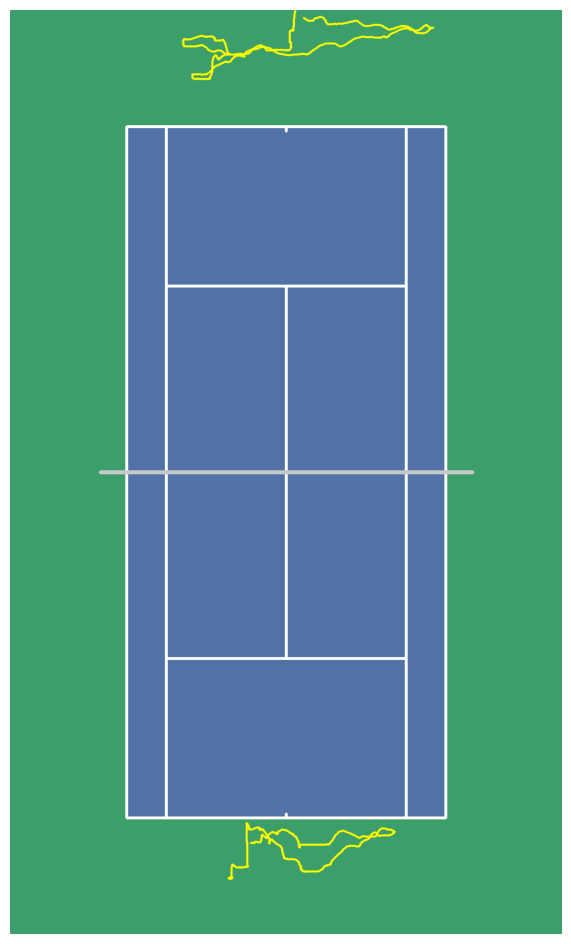

In [58]:
#visualize new player paths:

player1_path_cl = mapped_points_players_cleaned[0::2]
player2_path_cl = mapped_points_players_cleaned[1::2]

all_player_paths_cl = [player1_path_cl, player2_path_cl]

cancha_prueba = td.draw_paths_on_court(all_player_paths_cl, padding=padding)
#td.cv2_imshow(cancha_prueba)
sv.plot_image(cancha_prueba)

## Distance run per player

Total distance covered by each player over the point, measured on the cleaned
trajectories. Validated on a single point so far, so it is worth re-checking against
more clips before trusting the absolute numbers.


In [59]:
#Calculate distance run during the point (for one player)

def calculate_distance_run(path):
  distance = 0
  for i in range(len(path)-1):
    distance += np.linalg.norm(np.array(path[i]) - np.array(path[i+1]))
  return distance


In [60]:
#player 1 distance run:
distance_run_player1 = calculate_distance_run(player1_path_cl)
#player 2 distance run:
distance_run_player2 = calculate_distance_run(player2_path_cl)

print(distance_run_player1)
print(distance_run_player2)

16.74238052301785
24.77904856064463


## Cumulative distance

Per-frame cumulative distance for each player, computed on the cleaned trajectories.


In [ ]:
def calculate_cumulative_distance(path):
    cumulative_distances = [0.0]
    current_distance = 0.0
    for i in range(len(path) - 1):
        current_distance += np.linalg.norm(np.array(path[i]) - np.array(path[i+1]))
        cumulative_distances.append(current_distance)
    return cumulative_distances

# Calculate cumulative distances for player 1
player1_cumulative_distances = calculate_cumulative_distance(player1_path_cl)

# Calculate cumulative distances for player 2
player2_cumulative_distances = calculate_cumulative_distance(player2_path_cl)

print(f"Player 1 Cumulative Distances (last value): {player1_cumulative_distances[-1]:.2f} meters")
print(f"Player 2 Cumulative Distances (last value): {player2_cumulative_distances[-1]:.2f} meters")

In [ ]:
video_xy_annotated = []
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.7
font_thickness = 2
text_color_p1 = (0, 0, 255)  # Red for Player 1 (BGR format)
text_color_p2 = (255, 0, 0)  # Blue for Player 2 (BGR format)
box_color = (0, 0, 0)        # Black background for text
box_alpha = 0.5              # Semi-transparent

# Iterate through each frame to draw the court, player positions, and cumulative distances
for i in range(len(player1_path_cl)):
    # Plot players' current positions on a newly drawn court
    player_positions_in_frame = [player1_path_cl[i], player2_path_cl[i]]
    current_court_frame = td.draw_points_on_court(
        player_positions_in_frame,
        padding=padding
    )

    # Get cumulative distances for the current frame
    dist_p1 = player1_cumulative_distances[i]
    dist_p2 = player2_cumulative_distances[i]

    text_p1 = f"P1 Dist: {dist_p1:.2f} m"
    text_p2 = f"P2 Dist: {dist_p2:.2f} m"

    # --- Draw Player 1 distance (top-left) ---
    (text_width_p1, text_height_p1), baseline_p1 = cv2.getTextSize(text_p1, font, font_scale, font_thickness)
    p1_box_start_x = 10
    p1_box_start_y = 10
    p1_box_end_x = p1_box_start_x + text_width_p1 + 20
    p1_box_end_y = p1_box_start_y + text_height_p1 + 20

    # Draw semi-transparent rectangle for P1
    overlay = current_court_frame.copy()
    cv2.rectangle(overlay, (p1_box_start_x, p1_box_start_y), (p1_box_end_x, p1_box_end_y), box_color, -1)
    current_court_frame = cv2.addWeighted(overlay, box_alpha, current_court_frame, 1 - box_alpha, 0)

    # Put text for P1
    cv2.putText(current_court_frame, text_p1, (p1_box_start_x + 10, p1_box_start_y + text_height_p1 + 10), font, font_scale, text_color_p1, font_thickness, cv2.LINE_AA)

    # --- Draw Player 2 distance (top-right) ---
    (text_width_p2, text_height_p2), baseline_p2 = cv2.getTextSize(text_p2, font, font_scale, font_thickness)
    p2_box_start_x = current_court_frame.shape[1] - text_width_p2 - 30
    p2_box_start_y = 10
    p2_box_end_x = current_court_frame.shape[1] - 10
    p2_box_end_y = p2_box_start_y + text_height_p2 + 20

    # Draw semi-transparent rectangle for P2
    overlay = current_court_frame.copy()
    cv2.rectangle(overlay, (p2_box_start_x, p2_box_start_y), (p2_box_end_x, p2_box_end_y), box_color, -1)
    current_court_frame = cv2.addWeighted(overlay, box_alpha, current_court_frame, 1 - box_alpha, 0)

    # Put text for P2
    cv2.putText(current_court_frame, text_p2, (p2_box_start_x + 10, p2_box_start_y + text_height_p2 + 10), font, font_scale, text_color_p2, font_thickness, cv2.LINE_AA)

    video_xy_annotated.append(current_court_frame)

# Update Video Variable
video_xy_cleaned = np.array(video_xy_annotated)

In [ ]:
import supervision as sv
from tqdm.notebook import tqdm
from pathlib import Path
import os
import cv2 # For getting image dimensions if needed

# Ensure HOME is defined if running this cell independently
HOME = Path(os.getcwd())

# Define SOURCE_VIDEO here to ensure it's available
SOURCE_VIDEO = "/content/my_video_clip.mp4"

# Define target video paths
SOURCE_VIDEO_PATH = Path(SOURCE_VIDEO)
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-map-cleaned-dist.mp4"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed-dist.mp4"

# Get video info from the generated frames in video_xy_cleaned
# Assuming all frames in video_xy_cleaned have the same dimensions and td.draw_court output is consistent
if len(video_xy_cleaned) > 0:
    first_frame = video_xy_cleaned[0]
    height, width, _ = first_frame.shape
    # Re-read original video info to get fps from the original video duration
    original_video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
    fps = original_video_info.fps
    total_frames = len(video_xy_cleaned)
    video_info_out = sv.VideoInfo(width=width, height=height, fps=fps, total_frames=total_frames)
else:
    raise ValueError("video_xy_cleaned is empty, cannot create video.")

print(f"Creating video from {len(video_xy_cleaned)} frames...")
with sv.VideoSink(TARGET_VIDEO_PATH, video_info_out) as sink:
    for frame_image in tqdm(video_xy_cleaned, desc="Writing video frames"):
        sink.write_frame(frame_image)

print(f"Video saved to {TARGET_VIDEO_PATH}")

# Compress the video
print(f"Compressing video to {TARGET_VIDEO_COMPRESSED_PATH}...")
!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}
print(f"Compressed video saved to {TARGET_VIDEO_COMPRESSED_PATH}")

from IPython.display import Video
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)


## Bounce detection

Implemented in `bounce.py`. The naive approach — peaks of the ball's image `y` — does
not work, because image `y` mixes two things: how far away the ball is and how high it
is off the court. Over a single shot the distance term dominates, so `y` often runs
straight through a bounce with no peak at all. What peaks of `y` actually mark is
*racket contacts*.

A bounce instead shows up as curvature: the ball's vertical velocity flips while its
motion in depth carries on, giving a sharp negative spike in `d2y/dt2`. Contacts spike
harder still, so contacts are located first and one bounce is taken from each interval
between them — contacts and bounces alternate through a rally.

Validated against hand-labelled bounces for this clip: 7/7, mean error 24 ms. Run
`python validate_bounce.py` to reproduce.


In [ ]:
import bounce as bd

# Detect racket contacts and bounces straight from the cached boxes; the module does
# its own NaN masking, interpolation and smoothing.
bounce_frames, stroke_frames = bd.detect_bounces(rectangles_ball)

# Smoothed trajectory, reused below to map each bounce onto the court.
ball_pixel_centers_smoothed = bd.smoothed_trajectory(rectangles_ball)

print(f"racket contacts ({len(stroke_frames)}): {stroke_frames.tolist()}")
print(f"bounces ({len(bounce_frames)}): {bounce_frames.tolist()}")


In [ ]:
# Only now is the homography valid: it describes the court plane, so it maps the ball
# correctly only on the frames where the ball is actually touching the ground.
ball_bounces_court_coords = [
    transform_point(ball_pixel_centers_smoothed[frame_idx], H)
    for frame_idx in bounce_frames
]

print("Bounce locations in court coordinates:")
for frame_idx, (x, y) in zip(bounce_frames, ball_bounces_court_coords):
    print(f"  frame {frame_idx:>3}  ({x:5.2f} m, {y:5.2f} m)")


In [ ]:
#visualize

cancha_prueba = td.draw_points_on_court(ball_bounces_court_coords  )
sv.plot_image(cancha_prueba)